In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.decomposition import PCA
import requests
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import torch, numpy as np, random

In [5]:


# =====================================================
# STEP 1: LOAD DATASET (download if missing)
# =====================================================
try:
    df = pd.read_csv("2025-02-10T11_2025-02-11T11_video_sent_2025-02-10T11_2025-02-11T11.csv")
except FileNotFoundError:
    response = requests.get("https://storage.googleapis.com/puffer-data-release/2025-02-10T11_2025-02-11T11/video_sent_2025-02-10T11_2025-02-11T11.csv")
    with open("2025-02-10T11_2025-02-11T11_video_sent_2025-02-10T11_2025-02-11T11.csv", 'wb') as f:
        f.write(response.content)
    df = pd.read_csv("2025-02-10T11_2025-02-11T11_video_sent_2025-02-10T11_2025-02-11T11.csv")

# Step 2: Remove unnecessary columns & rename columns
#df = df.drop(columns=['session_id', 'channel', 'format'])
df = df.rename(columns={'time (ns GMT)': 'time'})
# make time relative to start of session and convert to seconds
df['time'] = (df['time'] - df['time'].min()) / 1e9

print(f"✅ Dataset loaded with {len(df)} rows")

✅ Dataset loaded with 5793735 rows


In [6]:
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

target_metric='delivery_rate'
n_lags=3
max_horizon=20
sample_size=800_000
plot_num=200

# Keep numeric columns but preserve session/time
df_numeric = df.select_dtypes(include=[np.number]).copy()
if 'session_id' in df.columns:
    df_numeric['session_id'] = df['session_id']
if 'time' in df.columns:
    df_numeric['time'] = df['time']

# Core features
base_features = ['cwnd', 'in_flight', 'min_rtt', 'rtt', 'delivery_rate', 'buffer']
feature_cols = [c for c in base_features if c in df_numeric.columns]

# Build lag features per session
dfs = []
print("Adding lag features per session...")
for sid, group in df_numeric.groupby('session_id',sort=False):
    g = group.sort_values('time').copy()
    for lag in range(1, n_lags + 1):
        for col in feature_cols:
            g[f"{col}_lag{lag}"] = g[col].shift(lag)

    # Create targets for all horizons
    for horizon in range(1, max_horizon + 1):
        g[f"{target_metric}_next{horizon}"] = g[target_metric].shift(-horizon)

    dfs.append(g)

# Combine all sessions and drop rows without full horizon data
#df_model = pd.concat(dfs, axis=0).dropna(subset=[f"{target_metric}_next{h}" for h in range(1, max_horizon + 1)]).reset_index(drop=True)
df_model = pd.concat(dfs, axis=0)
lag_cols = [f"{col}_lag{lag}" for col in base_features for lag in range(1, n_lags+1) if f"{col}_lag{lag}" in df_model.columns]
target_cols = [f"{target_metric}_next{h}" for h in range(1, max_horizon+1)]
df_model = df_model.dropna(subset=lag_cols + target_cols).reset_index(drop=True)

# Optional subsample
if len(df_model) > sample_size:
    df_model = df_model.iloc[:sample_size].reset_index(drop=True)

# Drop non-feature columns
df_model = df_model.drop(columns=['session_id', 'time'], errors='ignore')

# Features
feature_cols = [
    c for c in df_model.columns
    if c.startswith(tuple(base_features)) and not c.startswith(f"{target_metric}_next")
]
X = df_model[feature_cols]

# Chronological split
train_size = int(len(df_model) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
print(f"Training size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

y = df_model[f"{target_metric}_next{horizon}"]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:] 

Adding lag features per session...
Training size: 640000, Test size: 160000


In [ ]:
RTT Graphs

In [ ]:
Regression


===== Horizon 1 =====
Iteration 1, loss = 1962902998.37265897
Validation score: 0.687875
Iteration 2, loss = 1728796848.62598515
Validation score: 0.690938
Iteration 3, loss = 1723906158.74888515
Validation score: 0.690936
Iteration 4, loss = 1724525700.82589650
Validation score: 0.690259
Iteration 5, loss = 1719513494.62570953
Validation score: 0.690901
Iteration 6, loss = 1705654021.41854548
Validation score: 0.696043
Iteration 7, loss = 1695068898.74727416
Validation score: 0.695200
Iteration 8, loss = 1683385503.51387858
Validation score: 0.698098
Iteration 9, loss = 1675943486.70545506
Validation score: 0.690978
Iteration 10, loss = 1669145698.46494913
Validation score: 0.696398
Iteration 11, loss = 1660020959.36002946
Validation score: 0.696464
Iteration 12, loss = 1662002173.95941949
Validation score: 0.699475
Iteration 13, loss = 1662774356.95866251
Validation score: 0.699819
Iteration 14, loss = 1653775023.19435358
Validation score: 0.699173
Iteration 15, loss = 1652162171.08

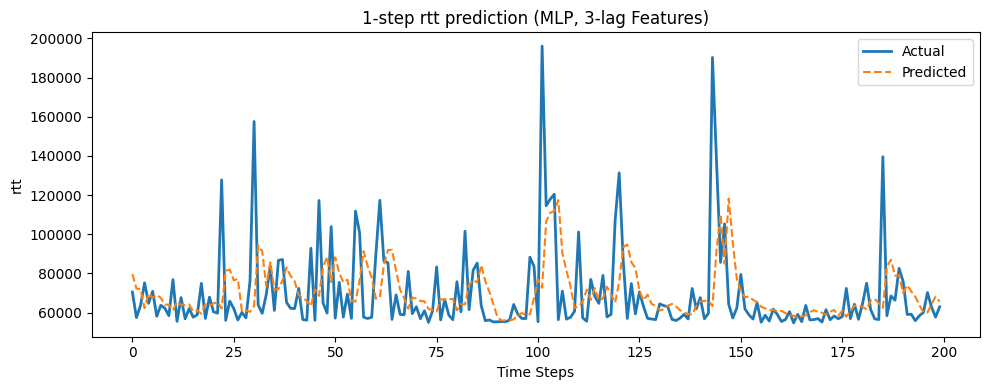


===== Horizon 2 =====
Iteration 1, loss = 2067135763.51459718
Validation score: 0.666496
Iteration 2, loss = 1827789992.01695061
Validation score: 0.666110
Iteration 3, loss = 1814088725.94155693
Validation score: 0.676352
Iteration 4, loss = 1775204631.89203668
Validation score: 0.681010
Iteration 5, loss = 1762859286.08764791
Validation score: 0.681950
Iteration 6, loss = 1755663529.12736249
Validation score: 0.680399
Iteration 7, loss = 1753030628.58493853
Validation score: 0.684819
Iteration 8, loss = 1750784990.24431109
Validation score: 0.685397
Iteration 9, loss = 1747354263.99507928
Validation score: 0.685315
Iteration 10, loss = 1746586821.56367111
Validation score: 0.683885
Iteration 11, loss = 1743489624.34214091
Validation score: 0.685702
Iteration 12, loss = 1741862484.57774782
Validation score: 0.680393
Iteration 13, loss = 1739465074.45583582
Validation score: 0.686914
Iteration 14, loss = 1738967900.58585835
Validation score: 0.685539
Iteration 15, loss = 1738134499.62

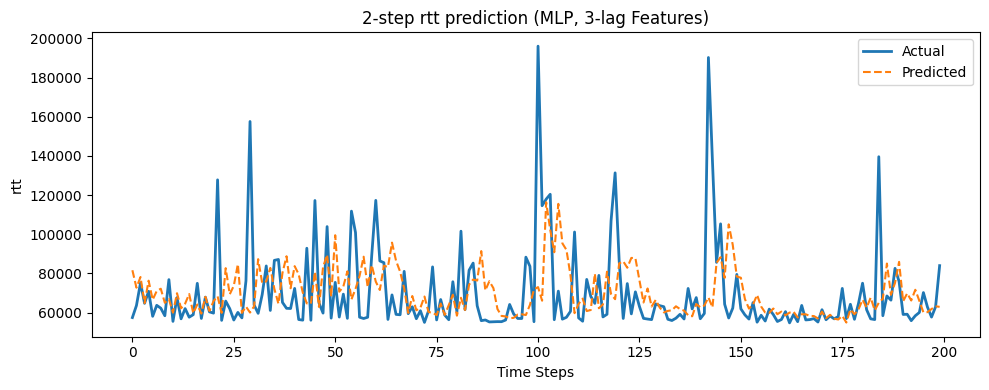


===== Horizon 4 =====
Iteration 1, loss = 2119426254.68932557
Validation score: 0.602793
Iteration 2, loss = 1872168048.67738271
Validation score: 0.607443
Iteration 3, loss = 1853876586.56262302
Validation score: 0.611202
Iteration 4, loss = 1845356180.06034017
Validation score: 0.613185
Iteration 5, loss = 1836096944.44649100
Validation score: 0.615133
Iteration 6, loss = 1822869052.20090413
Validation score: 0.622179
Iteration 7, loss = 1798298410.08703971
Validation score: 0.625976
Iteration 8, loss = 1783500944.89645338
Validation score: 0.628824
Iteration 9, loss = 1778633274.75759339
Validation score: 0.624020
Iteration 10, loss = 1775859694.15275908
Validation score: 0.631556
Iteration 11, loss = 1769796189.95588422
Validation score: 0.631979
Iteration 12, loss = 1767936227.51526713
Validation score: 0.621767
Iteration 13, loss = 1765726874.59052753
Validation score: 0.632352
Iteration 14, loss = 1762616930.37914705
Validation score: 0.632409
Iteration 15, loss = 1760198536.38

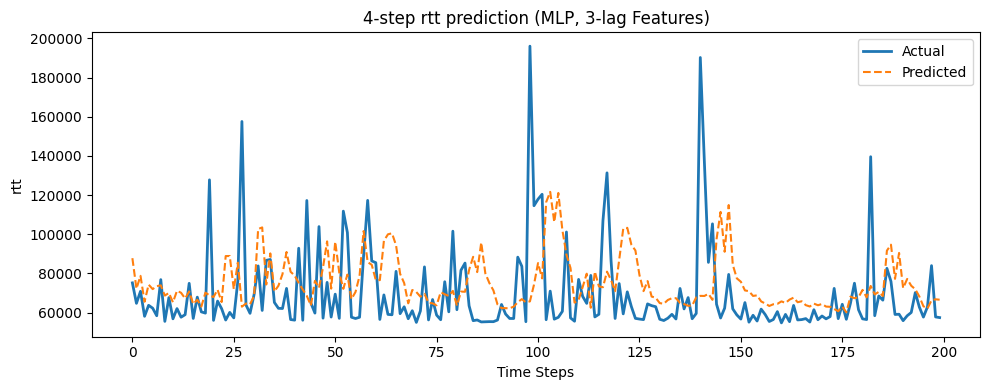


===== Horizon 8 =====
Iteration 1, loss = 2015034781.92057776
Validation score: 0.492320
Iteration 2, loss = 1772587735.36414480
Validation score: 0.496152
Iteration 3, loss = 1751481141.55853057
Validation score: 0.499976
Iteration 4, loss = 1735682132.01131415
Validation score: 0.502026
Iteration 5, loss = 1706810511.05261469
Validation score: 0.512381
Iteration 6, loss = 1678403798.42916179
Validation score: 0.513196
Iteration 7, loss = 1670277652.63224220
Validation score: 0.513047
Iteration 8, loss = 1665831844.08883452
Validation score: 0.515831
Iteration 9, loss = 1657095222.68896866
Validation score: 0.451768
Iteration 10, loss = 1661614571.09830785
Validation score: 0.516959
Iteration 11, loss = 1653485220.76568294
Validation score: 0.499569
Iteration 12, loss = 1650654490.96506667
Validation score: 0.515922
Iteration 13, loss = 1647363002.66084814
Validation score: 0.515727
Iteration 14, loss = 1644317738.96990085
Validation score: 0.516890
Iteration 15, loss = 1641901379.89

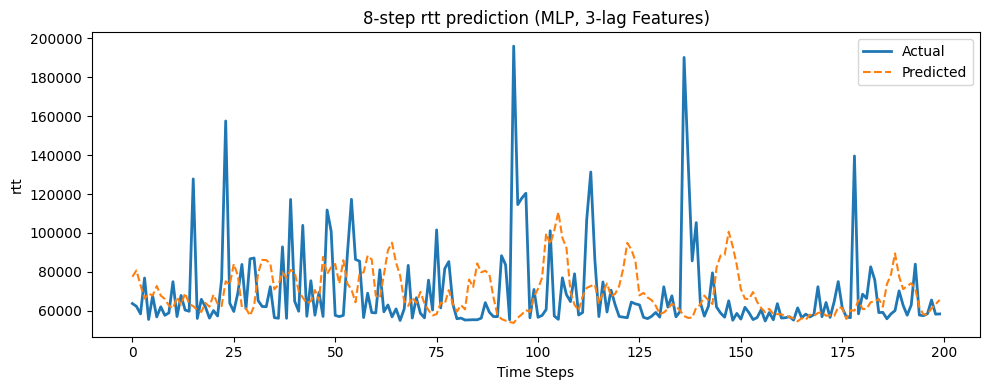


===== Horizon 16 =====
Iteration 1, loss = 2154599823.03223372
Validation score: 0.628021
Iteration 2, loss = 1895766841.93739510
Validation score: 0.629570
Iteration 3, loss = 1879842801.13368320
Validation score: 0.640518
Iteration 4, loss = 1858002966.98144794
Validation score: 0.646544
Iteration 5, loss = 1840481449.80493784
Validation score: 0.647155
Iteration 6, loss = 1827960617.29965353
Validation score: 0.654567
Iteration 7, loss = 1812827279.73311925
Validation score: 0.655340
Iteration 8, loss = 1805517852.32762170
Validation score: 0.657298
Iteration 9, loss = 1803587049.90273929
Validation score: 0.658549
Iteration 10, loss = 1799155606.32595301
Validation score: 0.658161
Iteration 11, loss = 1795794303.46066308
Validation score: 0.658236
Iteration 12, loss = 1793274717.65656066
Validation score: 0.660324
Iteration 13, loss = 1790779447.67266655
Validation score: 0.658080
Iteration 14, loss = 1789022641.17876577
Validation score: 0.658006
Iteration 15, loss = 1786896132.4

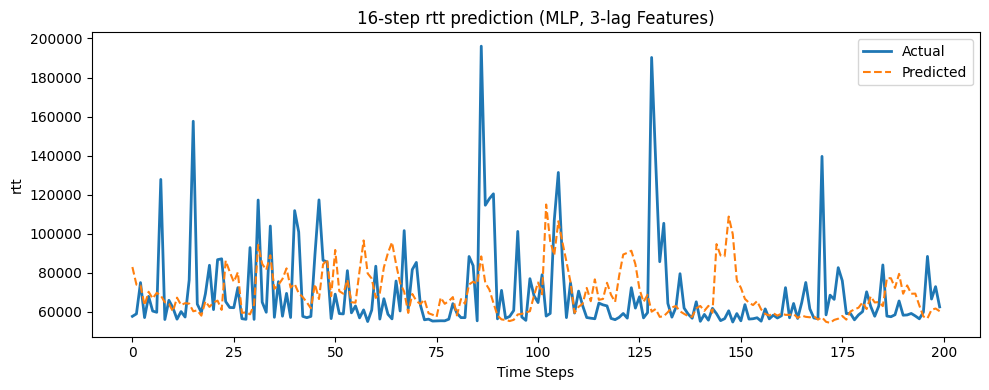

In [9]:
# Normalize features
# -------------------------------
scaler = StandardScaler()
X_train_scal = scaler.fit_transform(X_train)
X_test_scal  = scaler.transform(X_test)

target = ['rtt']

# List of horizons you want to evaluate
horizons = [1,2,4,8,16]

for horizon in horizons:
    print(f"\n===== Horizon {horizon} =====")
    
    # -------------------------------
    # Prepare target
    # -------------------------------
    y = df_model[f"{target_metric}_next{horizon}"]
    y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]
    
    # -------------------------------
    # Create and train MLP
    # -------------------------------
    mlp_model = MLPRegressor(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        solver='adam',
        learning_rate_init=0.005,
        max_iter=80,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        verbose=True
    )
    
    mlp_model.fit(X_train_scal, y_train)
    
    # -------------------------------
    # Predictions
    # -------------------------------
    y_train_pred = mlp_model.predict(X_train_scal)
    y_test_pred  = mlp_model.predict(X_test_scal)
    
    # -------------------------------
    # Evaluation
    # -------------------------------
    mae_train = mean_absolute_error(y_train, y_train_pred)
    r2_train  = r2_score(y_train, y_train_pred)
    mae_test  = mean_absolute_error(y_test, y_test_pred)
    r2_test   = r2_score(y_test, y_test_pred)
    
    print(f"📊 Results for {target} ({horizon}-step ahead):")
    print(f"Training → MAE: {mae_train:.2f}, R²: {r2_train:.3f}")
    print(f"Validation → MAE: {mae_test:.2f}, R²: {r2_test:.3f}")
    
    # -------------------------------
    # Plot predictions vs actual values
    # -------------------------------
    plot_n = min(200, len(y_test))
    plt.figure(figsize=(10,4))
    plt.plot(y_test.values[:plot_n], label='Actual', linewidth=2)
    plt.plot(y_test_pred[:plot_n], label='Predicted', linestyle='--')
    plt.title(f'{horizon}-step {target[0]} prediction (MLP, {n_lags}-lag Features)')
    plt.xlabel('Time Steps')
    plt.ylabel(target_metric)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
Quantile regression


===== Horizon 1 =====
Training quantile 0.25 for horizon 1...
Q=0.25 Epoch 25/300 Loss=0.0569
Q=0.25 Epoch 50/300 Loss=0.0477
Q=0.25 Epoch 75/300 Loss=0.0475
Q=0.25 Epoch 100/300 Loss=0.0460
Q=0.25 Epoch 125/300 Loss=0.0454
Q=0.25 Epoch 150/300 Loss=0.0448
Q=0.25 Epoch 175/300 Loss=0.0455
Q=0.25 Epoch 200/300 Loss=0.0442
Q=0.25 Epoch 225/300 Loss=0.0452
Training quantile 0.5 for horizon 1...
Q=0.5 Epoch 25/300 Loss=0.0822
Q=0.5 Epoch 50/300 Loss=0.0740
Q=0.5 Epoch 75/300 Loss=0.0724
Q=0.5 Epoch 100/300 Loss=0.0722
Q=0.5 Epoch 125/300 Loss=0.0714
Q=0.5 Epoch 150/300 Loss=0.0711
Q=0.5 Epoch 175/300 Loss=0.0707
Q=0.5 Epoch 200/300 Loss=0.0703
Q=0.5 Epoch 225/300 Loss=0.0701
Q=0.5 Epoch 250/300 Loss=0.0696
Q=0.5 Epoch 275/300 Loss=0.0695
Q=0.5 Epoch 300/300 Loss=0.0688
Training quantile 0.75 for horizon 1...
Q=0.75 Epoch 25/300 Loss=0.0853
Q=0.75 Epoch 50/300 Loss=0.0808
Q=0.75 Epoch 75/300 Loss=0.0765
Q=0.75 Epoch 100/300 Loss=0.0775
Q=0.75 Epoch 125/300 Loss=0.0757
Q=0.75 Epoch 150/300 

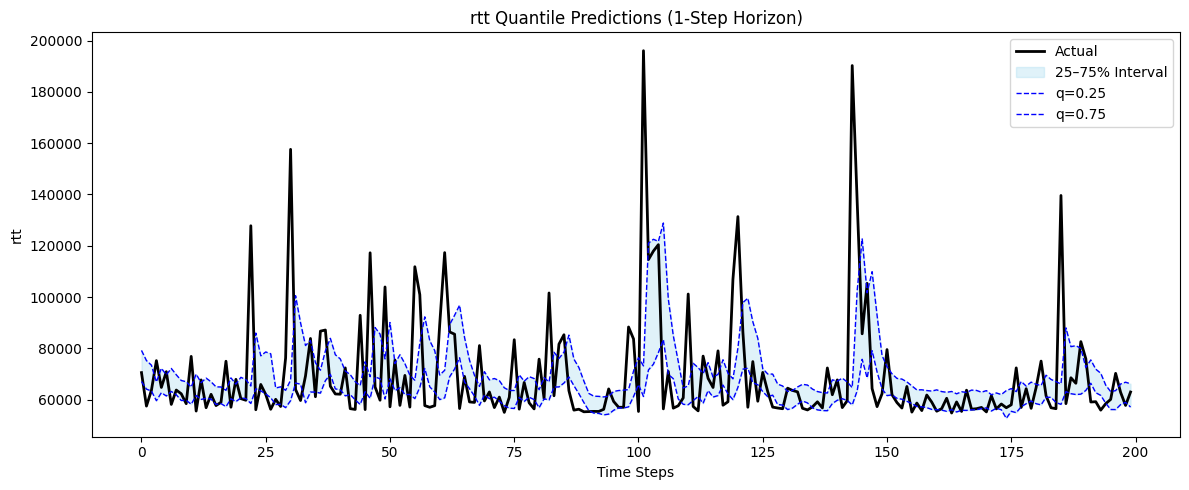


===== Horizon 4 =====
Training quantile 0.25 for horizon 4...
Q=0.25 Epoch 25/300 Loss=0.0583
Q=0.25 Epoch 50/300 Loss=0.0486
Q=0.25 Epoch 75/300 Loss=0.0471
Q=0.25 Epoch 100/300 Loss=0.0465
Q=0.25 Epoch 125/300 Loss=0.0461
Q=0.25 Epoch 150/300 Loss=0.0459
Training quantile 0.5 for horizon 4...
Q=0.5 Epoch 25/300 Loss=0.0911
Q=0.5 Epoch 50/300 Loss=0.0769
Q=0.5 Epoch 75/300 Loss=0.0743
Q=0.5 Epoch 100/300 Loss=0.0733
Q=0.5 Epoch 125/300 Loss=0.0728
Q=0.5 Epoch 150/300 Loss=0.0728
Q=0.5 Epoch 175/300 Loss=0.0725
Q=0.5 Epoch 200/300 Loss=0.0722
Q=0.5 Epoch 225/300 Loss=0.0724
Q=0.5 Epoch 250/300 Loss=0.0723
Q=0.5 Epoch 275/300 Loss=0.0716
Q=0.5 Epoch 300/300 Loss=0.0721
Training quantile 0.75 for horizon 4...
Q=0.75 Epoch 25/300 Loss=0.0942
Q=0.75 Epoch 50/300 Loss=0.0821
Q=0.75 Epoch 75/300 Loss=0.0805
Q=0.75 Epoch 100/300 Loss=0.0794
Q=0.75 Epoch 125/300 Loss=0.0789
Horizon 4 → Coverage: 59.18%, Avg. interval width: 20979.1211


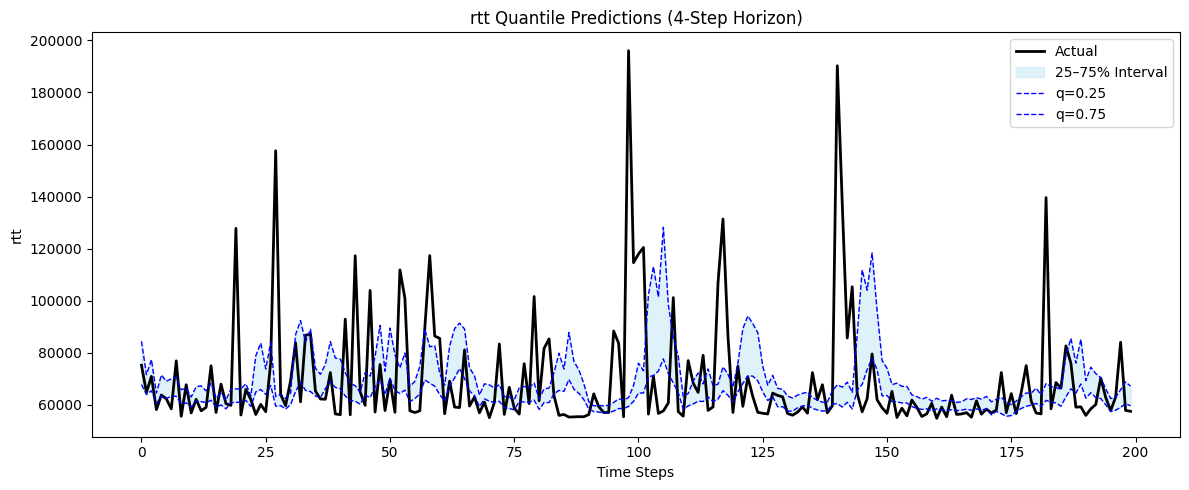


===== Horizon 16 =====
Training quantile 0.25 for horizon 16...
Q=0.25 Epoch 25/300 Loss=0.0639
Q=0.25 Epoch 50/300 Loss=0.0497
Q=0.25 Epoch 75/300 Loss=0.0478
Q=0.25 Epoch 100/300 Loss=0.0471
Q=0.25 Epoch 125/300 Loss=0.0463
Q=0.25 Epoch 150/300 Loss=0.0460
Training quantile 0.5 for horizon 16...
Q=0.5 Epoch 25/300 Loss=0.0855
Q=0.5 Epoch 50/300 Loss=0.0781
Q=0.5 Epoch 75/300 Loss=0.0769
Q=0.5 Epoch 100/300 Loss=0.0746
Q=0.5 Epoch 125/300 Loss=0.0740
Q=0.5 Epoch 150/300 Loss=0.0747
Q=0.5 Epoch 175/300 Loss=0.0740
Q=0.5 Epoch 200/300 Loss=0.0733
Q=0.5 Epoch 225/300 Loss=0.0742
Q=0.5 Epoch 250/300 Loss=0.0732
Q=0.5 Epoch 275/300 Loss=0.0727
Q=0.5 Epoch 300/300 Loss=0.0736
Training quantile 0.75 for horizon 16...
Q=0.75 Epoch 25/300 Loss=0.0913
Q=0.75 Epoch 50/300 Loss=0.0840
Q=0.75 Epoch 75/300 Loss=0.0833
Q=0.75 Epoch 100/300 Loss=0.0821
Q=0.75 Epoch 125/300 Loss=0.0806
Q=0.75 Epoch 150/300 Loss=0.0801
Q=0.75 Epoch 175/300 Loss=0.0998
Horizon 16 → Coverage: 62.48%, Avg. interval width

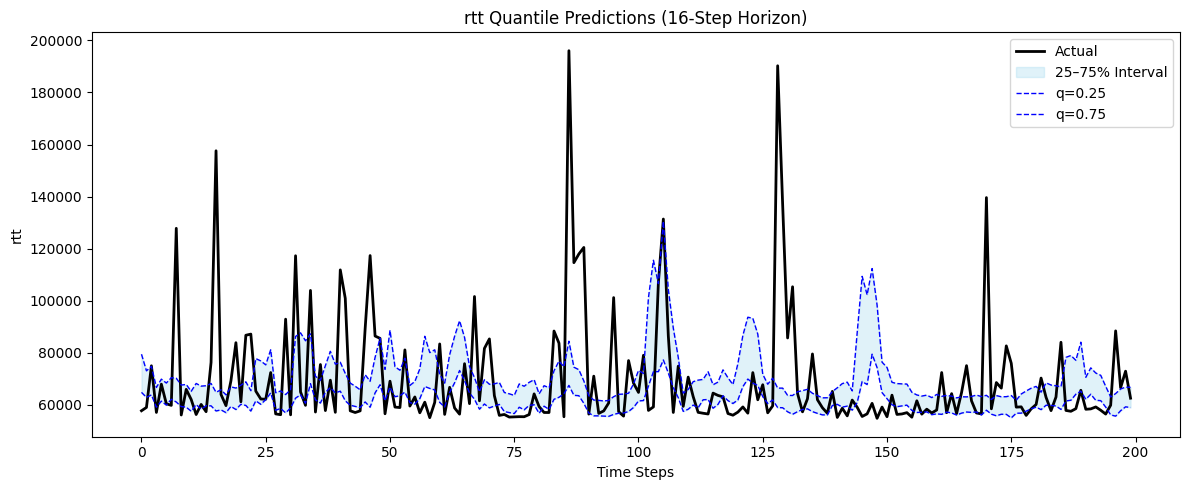

In [10]:
quantiles = [0.25, 0.5, 0.75]
plot_num = 200

# ============================================================
# SCALE FEATURES
# ============================================================
scaler_x = StandardScaler()
X_train_scal = scaler_x.fit_transform(X_train)
X_test_scal = scaler_x.transform(X_test)

X_train_tensor = torch.tensor(X_train_scal, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test_scal, dtype=torch.float32)

# ============================================================
# DEFINE QUANTILE LOSS
# ============================================================
def quantile_loss(pred, target, q):
    e = target - pred
    return torch.mean(torch.max(q*e, (q-1)*e))

# ============================================================
# DEFINE MLP MODEL
# ============================================================
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

# ============================================================
# TRAINING FUNCTION WITH EARLY STOPPING
# ============================================================
def train_quantile_model(X, y, q, epochs=300, lr=0.005, patience=20):
    model = MLP(X.shape[1])
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    best_loss = np.inf
    wait = 0

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        pred = model(X).squeeze()
        loss = quantile_loss(pred, y, q)
        loss.backward()
        optimizer.step()

        # Early stopping
        if loss.item() < best_loss - 1e-5:
            best_loss = loss.item()
            wait = 0
            best_state = model.state_dict()
        else:
            wait += 1
        
        if wait >= patience:
            break

        if (epoch+1) % 25 == 0:
            print(f"Q={q} Epoch {epoch+1}/{epochs} Loss={loss.item():.4f}")

    model.load_state_dict(best_state)
    return model

# ============================================================
# MULTI-HORIZON QUANTILE REGRESSION
# ============================================================
models_h = {}
preds_test_h = {}
coverages_h = {}
avg_widths_h = {}

for horizon in [1, 4, 16]:
    print(f"\n===== Horizon {horizon} =====")
    
    # -------------------------------
    # Prepare target
    # -------------------------------
    scaler_y = StandardScaler()  # new scaler per horizon
    y_train_np = df_model[f"{target_metric}_next{horizon}"].iloc[:train_size].values.reshape(-1,1)
    y_test_np  = df_model[f"{target_metric}_next{horizon}"].iloc[train_size:].values.reshape(-1,1)
    
    y_train_scal = scaler_y.fit_transform(y_train_np).flatten()
    y_test_scal  = scaler_y.transform(y_test_np).flatten()
    
    y_train_tensor = torch.tensor(y_train_scal, dtype=torch.float32)
    y_test_tensor  = torch.tensor(y_test_scal, dtype=torch.float32)
    
    models_h[horizon] = {}
    preds_test_h[horizon] = {}
    
    # -------------------------------
    # Train models for each quantile
    # -------------------------------
    for q in quantiles:
        print(f"Training quantile {q} for horizon {horizon}...")
        model = train_quantile_model(X_train_tensor, y_train_tensor, q=q)
        models_h[horizon][q] = model
        
        with torch.no_grad():
            pred_scaled = model(X_test_tensor).numpy().flatten()
        preds_test_h[horizon][q] = scaler_y.inverse_transform(pred_scaled.reshape(-1,1)).flatten()
    
    # -------------------------------
    # Coverage & Avg Interval Width
    # -------------------------------
    pred_25 = preds_test_h[horizon][0.25]
    pred_75 = preds_test_h[horizon][0.75]
    y_test_original = scaler_y.inverse_transform(y_test_scal.reshape(-1,1)).flatten()
    
    inside = (pred_25 <= y_test_original) & (y_test_original <= pred_75)
    coverages_h[horizon] = inside.mean()
    avg_widths_h[horizon] = (pred_75 - pred_25).mean()
    
    print(f"Horizon {horizon} → Coverage: {coverages_h[horizon]*100:.2f}%, Avg. interval width: {avg_widths_h[horizon]:.4f}")
    
    # -------------------------------
    # Plot first 200 samples
    # -------------------------------
    plot_n = min(plot_num, len(y_test_original))
    plt.figure(figsize=(12,5))
    plt.plot(y_test_original[:plot_n], color='black', linewidth=2, label='Actual')
    plt.fill_between(range(plot_n),
                     pred_25[:plot_n],
                     pred_75[:plot_n],
                     alpha=0.25, color='skyblue', label='25–75% Interval')
    plt.plot(pred_25[:plot_n], '--', color='blue', linewidth=1, label='q=0.25')
    plt.plot(pred_75[:plot_n], '--', color='blue', linewidth=1, label='q=0.75')
    plt.title(f"{target_metric} Quantile Predictions ({horizon}-Step Horizon)")
    plt.xlabel("Time Steps")
    plt.ylabel(target_metric)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
Delivery_rate graphs

In [ ]:
Regression


===== Horizon 1 =====
Iteration 1, loss = 51403621881006.52343750
Validation score: 0.661020
Iteration 2, loss = 32307863559117.97265625
Validation score: 0.699500
Iteration 3, loss = 30671201006703.41406250
Validation score: 0.707581
Iteration 4, loss = 30148502714993.89062500
Validation score: 0.711141
Iteration 5, loss = 29865027852554.11718750
Validation score: 0.712796
Iteration 6, loss = 29681778003046.01953125
Validation score: 0.713441
Iteration 7, loss = 29545518669487.50390625
Validation score: 0.715506
Iteration 8, loss = 29261170840224.52343750
Validation score: 0.719471
Iteration 9, loss = 28809229321557.14062500
Validation score: 0.723491
Iteration 10, loss = 28442357227760.19531250
Validation score: 0.730252
Iteration 11, loss = 27722380257769.30078125
Validation score: 0.735057
Iteration 12, loss = 27384931407877.23046875
Validation score: 0.737758
Iteration 13, loss = 27211128202594.97656250
Validation score: 0.739559
Iteration 14, loss = 27060317642507.87890625
Valid

C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (80) reached and the optimization hasn't converged yet.
  warnings.warn(


📊 Results for ['delivery_rate'] (1-step ahead):
Training → MAE: 2995450.51, R²: 0.760
Validation → MAE: 2175505.11, R²: 0.633


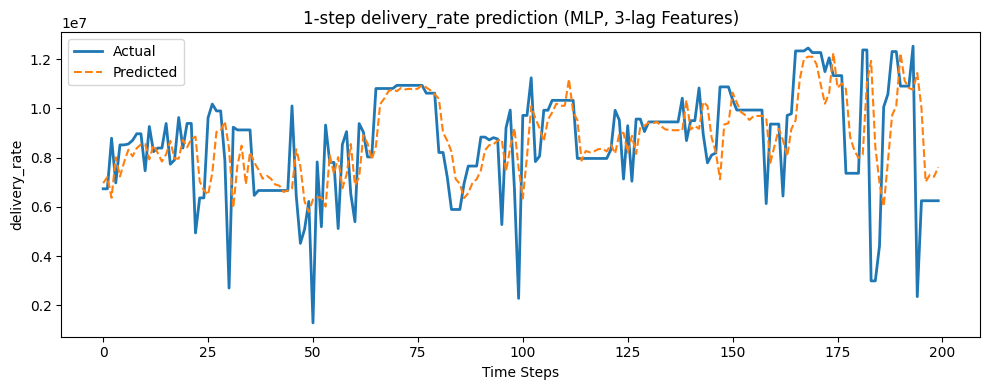


===== Horizon 2 =====
Iteration 1, loss = 43182706940100.57812500
Validation score: 0.675132
Iteration 2, loss = 33138540501652.39453125
Validation score: 0.686989
Iteration 3, loss = 31877572420143.10937500
Validation score: 0.698736
Iteration 4, loss = 31046131957928.16796875
Validation score: 0.701060
Iteration 5, loss = 30781169074283.86328125
Validation score: 0.703685
Iteration 6, loss = 30676936700024.19921875
Validation score: 0.703996
Iteration 7, loss = 30592159482386.92968750
Validation score: 0.703559
Iteration 8, loss = 30553873497710.49609375
Validation score: 0.704568
Iteration 9, loss = 30526193945874.69921875
Validation score: 0.705268
Iteration 10, loss = 30495099265306.22656250
Validation score: 0.705413
Iteration 11, loss = 30463887085574.74218750
Validation score: 0.704315
Iteration 12, loss = 30436470405114.43750000
Validation score: 0.705151
Iteration 13, loss = 30421499517098.00000000
Validation score: 0.703660
Iteration 14, loss = 30407260198314.27734375
Valid

C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (80) reached and the optimization hasn't converged yet.
  warnings.warn(


📊 Results for ['delivery_rate'] (2-step ahead):
Training → MAE: 3156430.54, R²: 0.735
Validation → MAE: 2231602.50, R²: 0.627


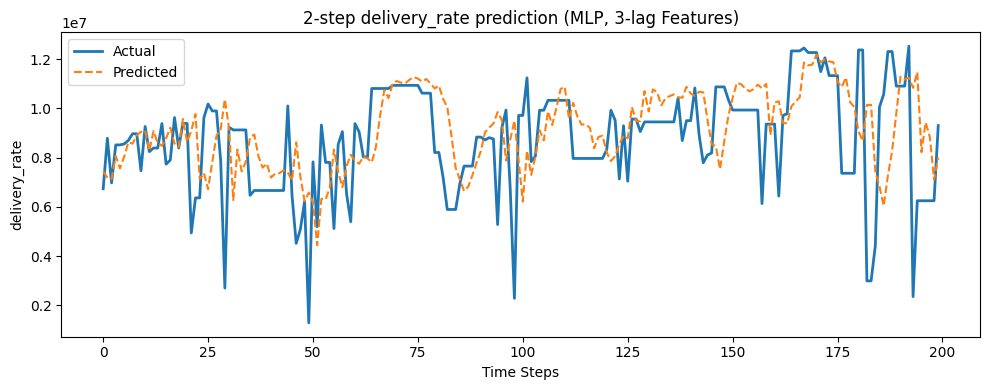


===== Horizon 4 =====
Iteration 1, loss = 41031396327749.76562500
Validation score: 0.694418
Iteration 2, loss = 31631415639490.41406250
Validation score: 0.699065
Iteration 3, loss = 31118431016268.01953125
Validation score: 0.703027
Iteration 4, loss = 30715013661323.03515625
Validation score: 0.706019
Iteration 5, loss = 30499328634478.20703125
Validation score: 0.704947
Iteration 6, loss = 30414595578466.51562500
Validation score: 0.707314
Iteration 7, loss = 30330454142408.87500000
Validation score: 0.707768
Iteration 8, loss = 30285503374025.87500000
Validation score: 0.706760
Iteration 9, loss = 30231684692930.51562500
Validation score: 0.708531
Iteration 10, loss = 30086253628118.73828125
Validation score: 0.711737
Iteration 11, loss = 29861820069925.96875000
Validation score: 0.712691
Iteration 12, loss = 29766739901142.26953125
Validation score: 0.712850
Iteration 13, loss = 29696876002380.19921875
Validation score: 0.714402
Iteration 14, loss = 29639101023041.55078125
Valid

C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (80) reached and the optimization hasn't converged yet.
  warnings.warn(


📊 Results for ['delivery_rate'] (4-step ahead):
Training → MAE: 3210369.94, R²: 0.737
Validation → MAE: 2317188.47, R²: 0.622


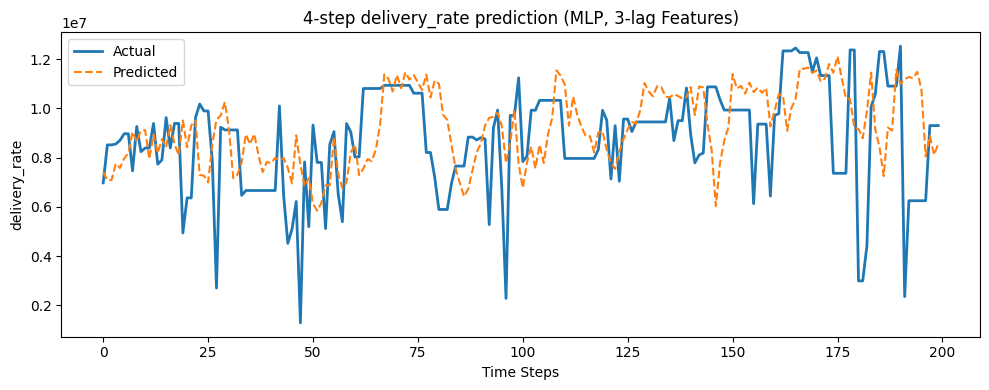


===== Horizon 8 =====
Iteration 1, loss = 54853069999556.48437500
Validation score: 0.602211
Iteration 2, loss = 36523367268596.92187500
Validation score: 0.631798
Iteration 3, loss = 35468358905977.48437500
Validation score: 0.636338
Iteration 4, loss = 35171701181922.08984375
Validation score: 0.639266
Iteration 5, loss = 34903355083099.84765625
Validation score: 0.641161
Iteration 6, loss = 34664471249201.19531250
Validation score: 0.642378
Iteration 7, loss = 34421324381105.29296875
Validation score: 0.646461
Iteration 8, loss = 34202632725732.89843750
Validation score: 0.648579
Iteration 9, loss = 34001556880061.46875000
Validation score: 0.650174
Iteration 10, loss = 33823976392137.79296875
Validation score: 0.650456
Iteration 11, loss = 33644659919892.30078125
Validation score: 0.654482
Iteration 12, loss = 33452935022716.30859375
Validation score: 0.656067
Iteration 13, loss = 33265208638835.22265625
Validation score: 0.658735
Iteration 14, loss = 32611696476507.61328125
Valid

C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (80) reached and the optimization hasn't converged yet.
  warnings.warn(


📊 Results for ['delivery_rate'] (8-step ahead):
Training → MAE: 3506690.15, R²: 0.714
Validation → MAE: 2591658.06, R²: 0.556


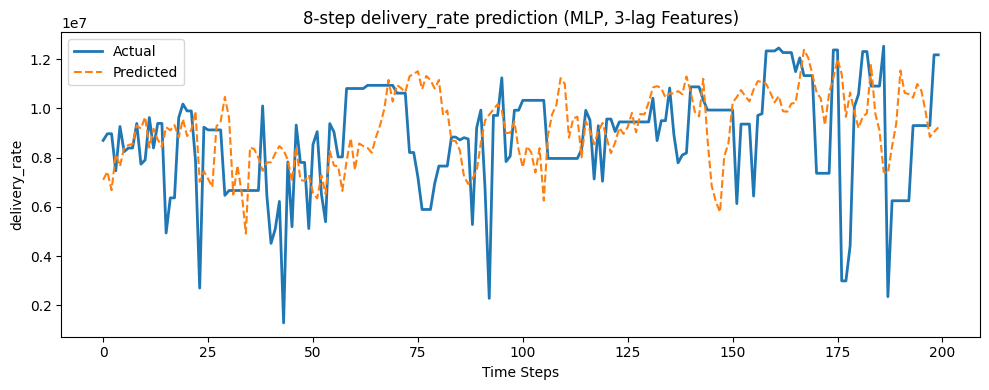


===== Horizon 16 =====
Iteration 1, loss = 45339413544112.75000000
Validation score: 0.646868
Iteration 2, loss = 36267922806492.51562500
Validation score: 0.650667
Iteration 3, loss = 35801083660939.53125000
Validation score: 0.654879
Iteration 4, loss = 35409056296929.54687500
Validation score: 0.657685
Iteration 5, loss = 35132061194345.83593750
Validation score: 0.657912
Iteration 6, loss = 34975398679664.61718750
Validation score: 0.661103
Iteration 7, loss = 34805602108668.91406250
Validation score: 0.662655
Iteration 8, loss = 34552298387961.54296875
Validation score: 0.666012
Iteration 9, loss = 34213767810314.98046875
Validation score: 0.669566
Iteration 10, loss = 33950288119502.13671875
Validation score: 0.671854
Iteration 11, loss = 33805599777239.62500000
Validation score: 0.673524
Iteration 12, loss = 33652776061833.77734375
Validation score: 0.671509
Iteration 13, loss = 33541862920021.51171875
Validation score: 0.675831
Iteration 14, loss = 33424917189144.75390625
Vali

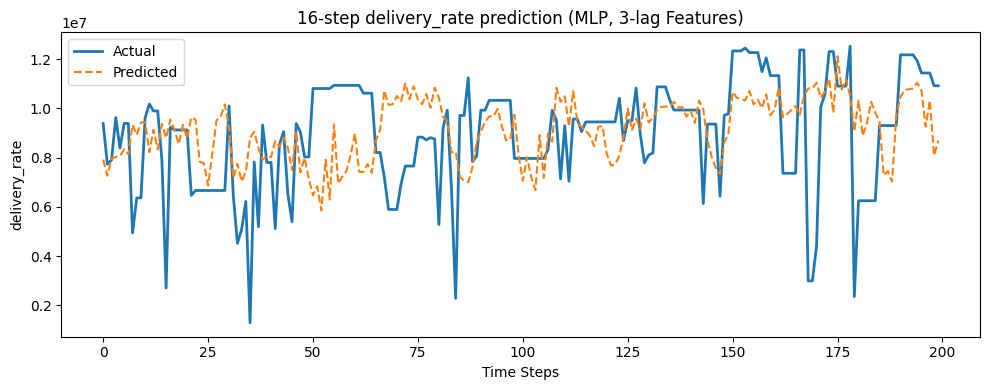

In [7]:
# Normalize features
# -------------------------------
scaler = StandardScaler()
X_train_scal = scaler.fit_transform(X_train)
X_test_scal  = scaler.transform(X_test)

target = ['delivery_rate']

# List of horizons you want to evaluate
horizons = [1,2,4,8,16]

for horizon in horizons:
    print(f"\n===== Horizon {horizon} =====")
    
    # -------------------------------
    # Prepare target
    # -------------------------------
    y = df_model[f"{target_metric}_next{horizon}"]
    y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]
    
    # -------------------------------
    # Create and train MLP
    # -------------------------------
    mlp_model = MLPRegressor(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        solver='adam',
        learning_rate_init=0.005,
        max_iter=80,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        verbose=True
    )
    
    mlp_model.fit(X_train_scal, y_train)
    
    # -------------------------------
    # Predictions
    # -------------------------------
    y_train_pred = mlp_model.predict(X_train_scal)
    y_test_pred  = mlp_model.predict(X_test_scal)
    
    # -------------------------------
    # Evaluation
    # -------------------------------
    mae_train = mean_absolute_error(y_train, y_train_pred)
    r2_train  = r2_score(y_train, y_train_pred)
    mae_test  = mean_absolute_error(y_test, y_test_pred)
    r2_test   = r2_score(y_test, y_test_pred)
    
    print(f"📊 Results for {target} ({horizon}-step ahead):")
    print(f"Training → MAE: {mae_train:.2f}, R²: {r2_train:.3f}")
    print(f"Validation → MAE: {mae_test:.2f}, R²: {r2_test:.3f}")
    
    # -------------------------------
    # Plot predictions vs actual values
    # -------------------------------
    plot_n = min(200, len(y_test))
    plt.figure(figsize=(10,4))
    plt.plot(y_test.values[:plot_n], label='Actual', linewidth=2)
    plt.plot(y_test_pred[:plot_n], label='Predicted', linestyle='--')
    plt.title(f'{horizon}-step {target[0]} prediction (MLP, {n_lags}-lag Features)')
    plt.xlabel('Time Steps')
    plt.ylabel(target_metric)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [52]:
"Quantile regression"

'Quantile regression'


===== Horizon 1 =====
Training quantile 0.25 for horizon 1...
Q=0.25 Epoch 25/300 Loss=0.1195
Q=0.25 Epoch 50/300 Loss=0.1049
Q=0.25 Epoch 75/300 Loss=0.0902
Q=0.25 Epoch 100/300 Loss=0.0876
Q=0.25 Epoch 125/300 Loss=0.0855
Q=0.25 Epoch 150/300 Loss=0.0844
Q=0.25 Epoch 175/300 Loss=0.0843
Training quantile 0.5 for horizon 1...
Q=0.5 Epoch 25/300 Loss=0.1338
Q=0.5 Epoch 50/300 Loss=0.1115
Q=0.5 Epoch 75/300 Loss=0.1052
Q=0.5 Epoch 100/300 Loss=0.1025
Q=0.5 Epoch 125/300 Loss=0.1005
Q=0.5 Epoch 150/300 Loss=0.0996
Q=0.5 Epoch 175/300 Loss=0.0987
Q=0.5 Epoch 200/300 Loss=0.0982
Q=0.5 Epoch 225/300 Loss=0.0971
Q=0.5 Epoch 250/300 Loss=0.0967
Q=0.5 Epoch 275/300 Loss=0.0961
Q=0.5 Epoch 300/300 Loss=0.0952
Training quantile 0.75 for horizon 1...
Q=0.75 Epoch 25/300 Loss=0.1062
Q=0.75 Epoch 50/300 Loss=0.0888
Q=0.75 Epoch 75/300 Loss=0.0847
Q=0.75 Epoch 100/300 Loss=0.0813
Q=0.75 Epoch 125/300 Loss=0.0797
Q=0.75 Epoch 150/300 Loss=0.0785
Q=0.75 Epoch 175/300 Loss=0.0774
Q=0.75 Epoch 200/300 

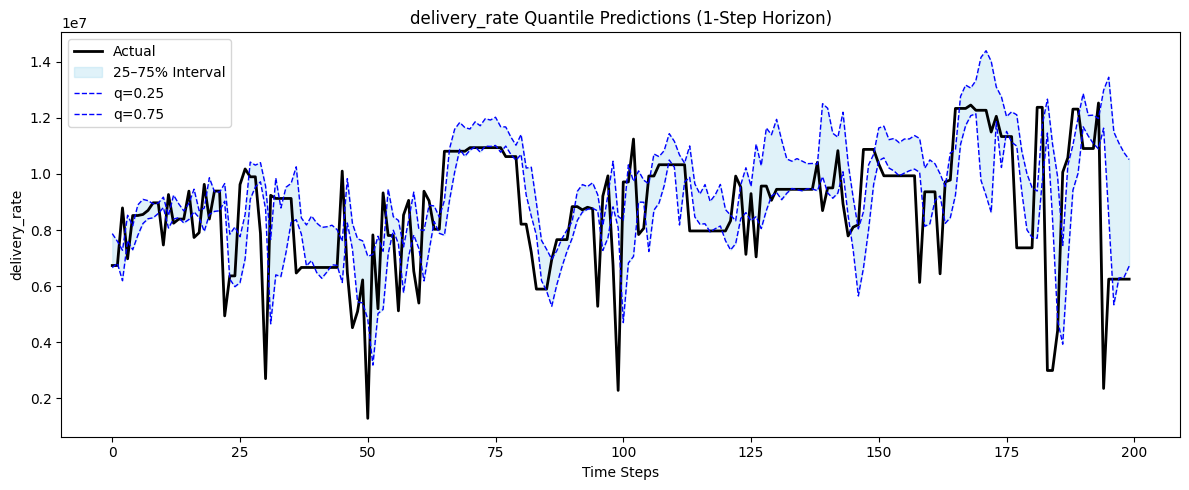


===== Horizon 4 =====
Training quantile 0.25 for horizon 4...
Q=0.25 Epoch 25/300 Loss=0.1051
Q=0.25 Epoch 50/300 Loss=0.0937
Q=0.25 Epoch 75/300 Loss=0.0908
Q=0.25 Epoch 100/300 Loss=0.0882
Q=0.25 Epoch 125/300 Loss=0.0884
Q=0.25 Epoch 150/300 Loss=0.0869
Q=0.25 Epoch 175/300 Loss=0.0885
Q=0.25 Epoch 200/300 Loss=0.0863
Q=0.25 Epoch 225/300 Loss=0.0863
Q=0.25 Epoch 250/300 Loss=0.0857
Q=0.25 Epoch 275/300 Loss=0.0867
Training quantile 0.5 for horizon 4...
Q=0.5 Epoch 25/300 Loss=0.1269
Q=0.5 Epoch 50/300 Loss=0.1189
Q=0.5 Epoch 75/300 Loss=0.1146
Q=0.5 Epoch 100/300 Loss=0.1118
Q=0.5 Epoch 125/300 Loss=0.1104
Q=0.5 Epoch 150/300 Loss=0.1095
Q=0.5 Epoch 175/300 Loss=0.1087
Q=0.5 Epoch 200/300 Loss=0.1078
Q=0.5 Epoch 225/300 Loss=0.1074
Q=0.5 Epoch 250/300 Loss=0.1070
Q=0.5 Epoch 275/300 Loss=0.1072
Q=0.5 Epoch 300/300 Loss=0.1066
Training quantile 0.75 for horizon 4...
Q=0.75 Epoch 25/300 Loss=0.1041
Q=0.75 Epoch 50/300 Loss=0.0922
Q=0.75 Epoch 75/300 Loss=0.0884
Q=0.75 Epoch 100/300 

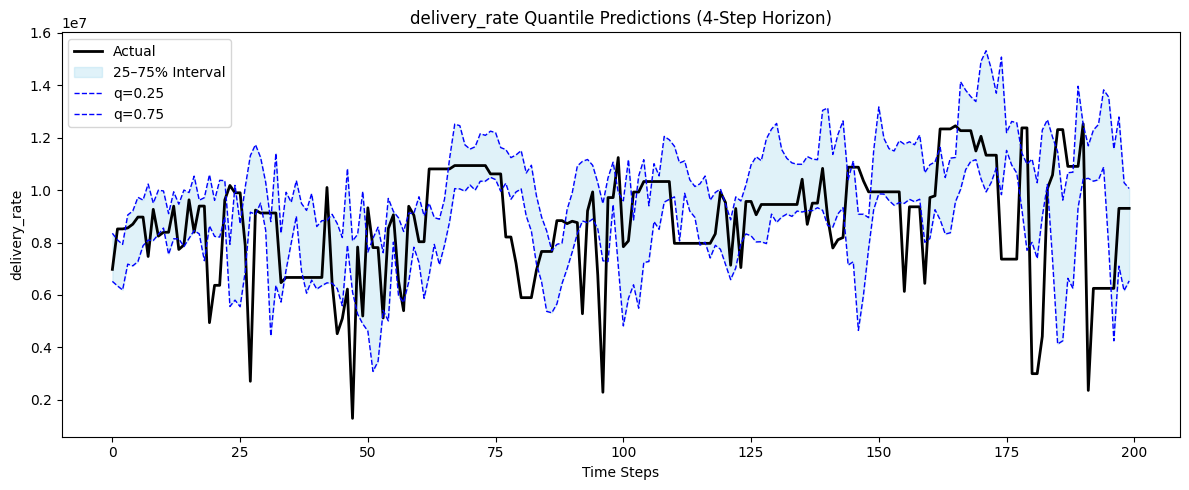


===== Horizon 16 =====
Training quantile 0.25 for horizon 16...
Q=0.25 Epoch 25/300 Loss=0.1134
Q=0.25 Epoch 50/300 Loss=0.1034
Q=0.25 Epoch 75/300 Loss=0.0999
Q=0.25 Epoch 100/300 Loss=0.0994
Q=0.25 Epoch 125/300 Loss=0.0979
Q=0.25 Epoch 150/300 Loss=0.0975
Q=0.25 Epoch 175/300 Loss=0.0970
Q=0.25 Epoch 200/300 Loss=0.0969
Q=0.25 Epoch 225/300 Loss=0.0967
Q=0.25 Epoch 250/300 Loss=0.0966
Training quantile 0.5 for horizon 16...
Q=0.5 Epoch 25/300 Loss=0.1361
Q=0.5 Epoch 50/300 Loss=0.1314
Q=0.5 Epoch 75/300 Loss=0.1288
Q=0.5 Epoch 100/300 Loss=0.1275
Q=0.5 Epoch 125/300 Loss=0.1263
Q=0.5 Epoch 150/300 Loss=0.1260
Q=0.5 Epoch 175/300 Loss=0.1250
Q=0.5 Epoch 200/300 Loss=0.1243
Q=0.5 Epoch 225/300 Loss=0.1256
Q=0.5 Epoch 250/300 Loss=0.1235
Q=0.5 Epoch 275/300 Loss=0.1235
Q=0.5 Epoch 300/300 Loss=0.1230
Training quantile 0.75 for horizon 16...
Q=0.75 Epoch 25/300 Loss=0.1182
Q=0.75 Epoch 50/300 Loss=0.1091
Q=0.75 Epoch 75/300 Loss=0.1063
Q=0.75 Epoch 100/300 Loss=0.1049
Q=0.75 Epoch 125/

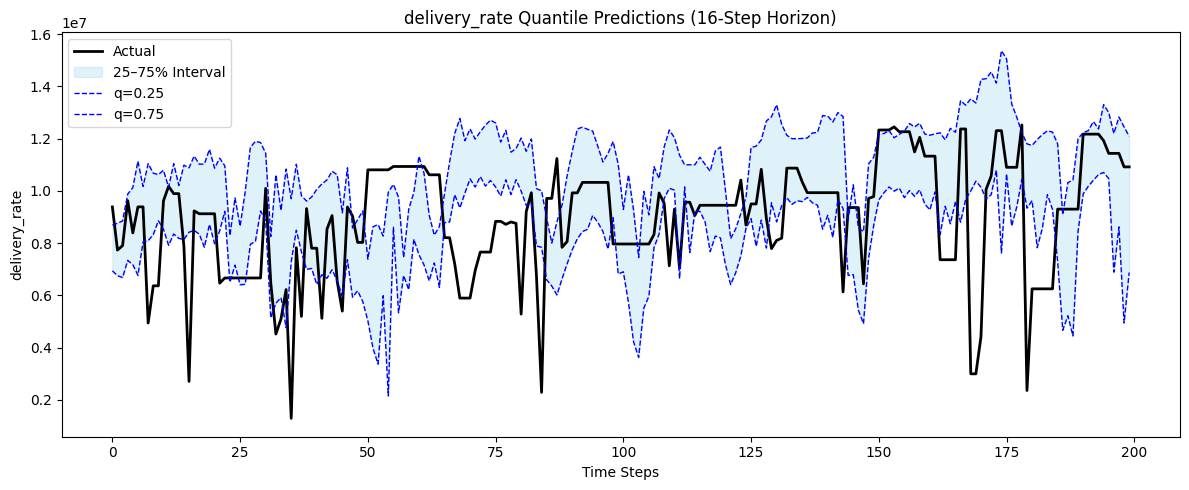

In [8]:
quantiles = [0.25, 0.5, 0.75]
plot_num = 200

# ============================================================
# SCALE FEATURES
# ============================================================
scaler_x = StandardScaler()
X_train_scal = scaler_x.fit_transform(X_train)
X_test_scal = scaler_x.transform(X_test)

X_train_tensor = torch.tensor(X_train_scal, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test_scal, dtype=torch.float32)

# ============================================================
# DEFINE QUANTILE LOSS
# ============================================================
def quantile_loss(pred, target, q):
    e = target - pred
    return torch.mean(torch.max(q*e, (q-1)*e))

# ============================================================
# DEFINE MLP MODEL
# ============================================================
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

# ============================================================
# TRAINING FUNCTION WITH EARLY STOPPING
# ============================================================
def train_quantile_model(X, y, q, epochs=300, lr=0.005, patience=20):
    model = MLP(X.shape[1])
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    best_loss = np.inf
    wait = 0

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        pred = model(X).squeeze()
        loss = quantile_loss(pred, y, q)
        loss.backward()
        optimizer.step()

        # Early stopping
        if loss.item() < best_loss - 1e-5:
            best_loss = loss.item()
            wait = 0
            best_state = model.state_dict()
        else:
            wait += 1
        
        if wait >= patience:
            break

        if (epoch+1) % 25 == 0:
            print(f"Q={q} Epoch {epoch+1}/{epochs} Loss={loss.item():.4f}")

    model.load_state_dict(best_state)
    return model

# ============================================================
# MULTI-HORIZON QUANTILE REGRESSION
# ============================================================
models_h = {}
preds_test_h = {}
coverages_h = {}
avg_widths_h = {}

for horizon in [1, 4, 16]:
    print(f"\n===== Horizon {horizon} =====")
    
    # -------------------------------
    # Prepare target
    # -------------------------------
    scaler_y = StandardScaler()  # new scaler per horizon
    y_train_np = df_model[f"{target_metric}_next{horizon}"].iloc[:train_size].values.reshape(-1,1)
    y_test_np  = df_model[f"{target_metric}_next{horizon}"].iloc[train_size:].values.reshape(-1,1)
    
    y_train_scal = scaler_y.fit_transform(y_train_np).flatten()
    y_test_scal  = scaler_y.transform(y_test_np).flatten()
    
    y_train_tensor = torch.tensor(y_train_scal, dtype=torch.float32)
    y_test_tensor  = torch.tensor(y_test_scal, dtype=torch.float32)
    
    models_h[horizon] = {}
    preds_test_h[horizon] = {}
    
    # -------------------------------
    # Train models for each quantile
    # -------------------------------
    for q in quantiles:
        print(f"Training quantile {q} for horizon {horizon}...")
        model = train_quantile_model(X_train_tensor, y_train_tensor, q=q)
        models_h[horizon][q] = model
        
        with torch.no_grad():
            pred_scaled = model(X_test_tensor).numpy().flatten()
        preds_test_h[horizon][q] = scaler_y.inverse_transform(pred_scaled.reshape(-1,1)).flatten()
    
    # -------------------------------
    # Coverage & Avg Interval Width
    # -------------------------------
    pred_25 = preds_test_h[horizon][0.25]
    pred_75 = preds_test_h[horizon][0.75]
    y_test_original = scaler_y.inverse_transform(y_test_scal.reshape(-1,1)).flatten()
    
    inside = (pred_25 <= y_test_original) & (y_test_original <= pred_75)
    coverages_h[horizon] = inside.mean()
    avg_widths_h[horizon] = (pred_75 - pred_25).mean()
    
    print(f"Horizon {horizon} → Coverage: {coverages_h[horizon]*100:.2f}%, Avg. interval width: {avg_widths_h[horizon]:.4f}")
    
    # -------------------------------
    # Plot first 200 samples
    # -------------------------------
    plot_n = min(plot_num, len(y_test_original))
    plt.figure(figsize=(12,5))
    plt.plot(y_test_original[:plot_n], color='black', linewidth=2, label='Actual')
    plt.fill_between(range(plot_n),
                     pred_25[:plot_n],
                     pred_75[:plot_n],
                     alpha=0.25, color='skyblue', label='25–75% Interval')
    plt.plot(pred_25[:plot_n], '--', color='blue', linewidth=1, label='q=0.25')
    plt.plot(pred_75[:plot_n], '--', color='blue', linewidth=1, label='q=0.75')
    plt.title(f"{target_metric} Quantile Predictions ({horizon}-Step Horizon)")
    plt.xlabel("Time Steps")
    plt.ylabel(target_metric)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
RTT R2 vs horizon graph

Text(0.5, 1.0, 'RTT MAE vs horizon')

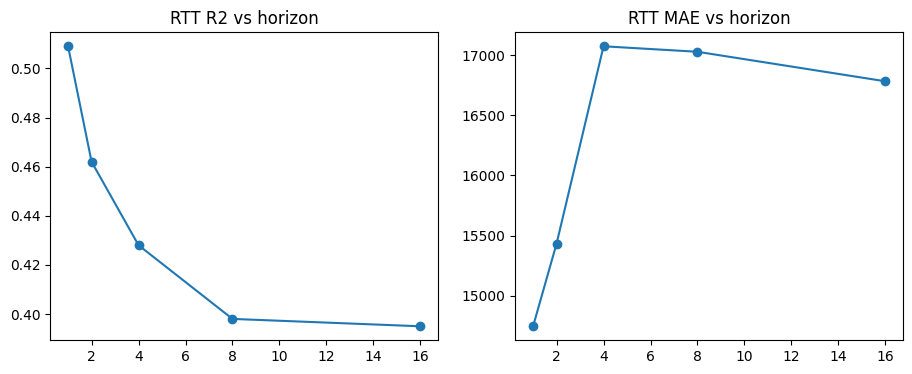

In [49]:
x = [1,2,4,8,16]
y = [0.509,0.462,0.428,0.398,0.395]
plt.figure(figsize=(11,4))
plt.subplot(1,2,1)
plt.plot(x,y,marker='o')
plt.title('RTT R2 vs horizon')
#----------------------------------------------------------
plt.subplot(1,2,2)
x = [1,2,4,8,16]
y = [14746.13,15433.40,17073.90,17028.13,16782.80]
plt.plot(x,y,marker='o')
plt.title('RTT MAE vs horizon')

Text(0.5, 1.0, 'Delivery rate MAE vs horizon')

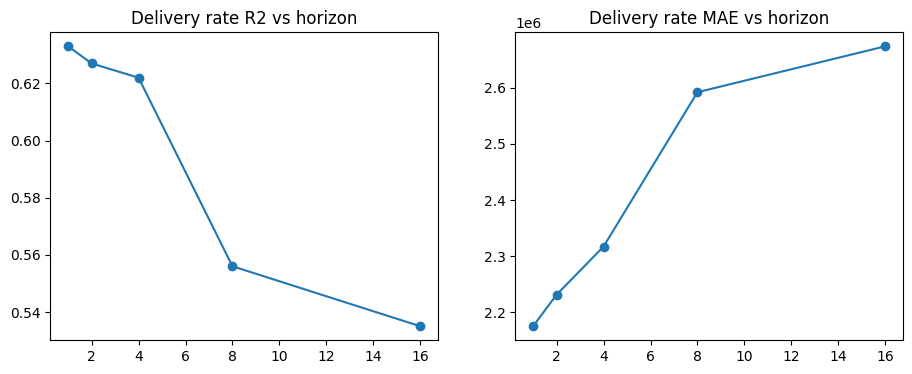

In [48]:
x = [1,2,4,8,16]
y = [0.633,0.627,0.622,0.556,0.535]
plt.figure(figsize=(11,4))
plt.subplot(1,2,1)
plt.plot(x,y,marker='o')
plt.title('Delivery rate R2 vs horizon')
#----------------------------------------------------------------------
plt.subplot(1,2,2)
x = [1,2,4,8,16]
y = [2175505.11,2231602.50,2317188.47,2591658.06,2673296.31]
plt.plot(x,y,marker='o')
plt.title('Delivery rate MAE vs horizon')

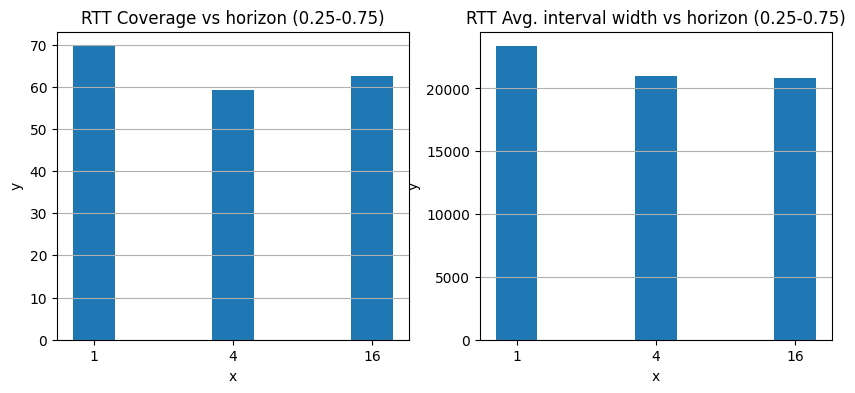

In [50]:
x = [1, 4,16]
y = [69.56,59.18,62.48]

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
# Treat x values as category labels to avoid gaps
plt.bar([str(i) for i in x], y,width=0.3)

plt.xlabel("x")
plt.ylabel("y")
plt.title("RTT Coverage vs horizon (0.25-0.75)")
plt.grid(True, axis='y')

#-------------------------------------------------------------------
plt.subplot(1,2,2)
x = [1, 4,16]
y = [23348.0098,20979.1211,20830.1895]

# Treat x values as category labels to avoid gaps
plt.bar([str(i) for i in x], y,width=0.3)

plt.xlabel("x")
plt.ylabel("y")
plt.title("RTT Avg. interval width vs horizon (0.25-0.75)")
plt.grid(True, axis='y')


plt.show()

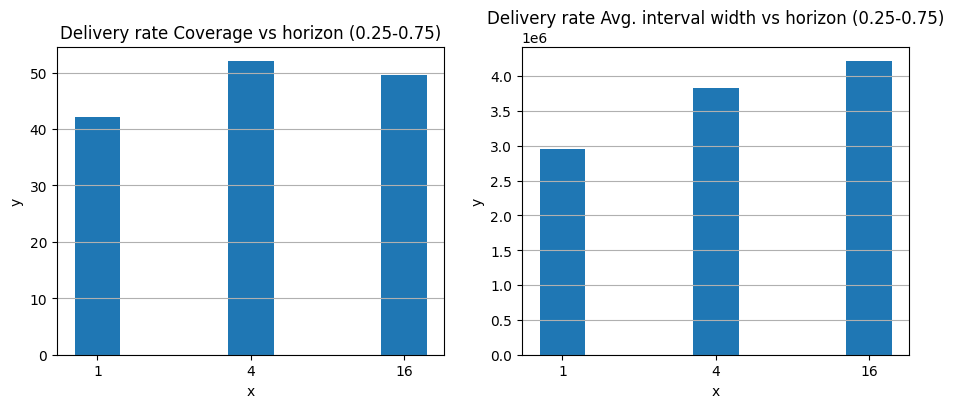

In [46]:
x = [1, 4,16]
y = [42.19,52.00,49.59]

plt.figure(figsize=(11,4))

plt.subplot(1,2,1)
# Treat x values as category labels to avoid gaps
plt.bar([str(i) for i in x], y,width=0.3)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Delivery rate Coverage vs horizon (0.25-0.75)")
plt.grid(True, axis='y')
#---------------------------------------------------------------------------
x = [1, 4,16]
y = [2957488.5000,3825771.2500,4210627.0000]

plt.subplot(1,2,2)

# Treat x values as category labels to avoid gaps
plt.bar([str(i) for i in x], y,width=0.3)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Delivery rate Avg. interval width vs horizon (0.25-0.75)")
plt.grid(True, axis='y')

plt.show()